Evaluation (glm-3-turbo, zero-shot)

Independent Variables:

Persona (Yes/No): Baseline vs. Persona Input Context: Claim vs. Claim+Premise vs. Claim+Premise+Argumentation

Prompting Technique: Zero-shot vs. One-shot

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd

with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/zero-shot/Claim_only_output.json", "r", encoding="utf-8") as f:
    claim_only = json.load(f)
with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/zero-shot/Claim_Premise_output.json", "r", encoding="utf-8") as f:
    claim_premise = json.load(f)
with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/zero-shot/Claim_Premise_Argumentation_output.json", "r", encoding="utf-8") as f:
    claim_prem_arg = json.load(f)

with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/glm-3-turbo_baseline_output.json", "r", encoding="utf-8") as f:
    baseline = json.load(f)

In [ ]:
PERSONAS = [
    "Rawlsian philosopher",
    "Libertarian economist",
    "Utilitarian ethicist",
    "Conservative political theorist"
]

def json_to_df(data, prompt_type):
    df = pd.DataFrame(data)
    df['prompt_type'] = prompt_type
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())
    df['argument'] = df['response'].apply(lambda x: x.split("Argument:")[1].strip())
    return df

df_baseline = json_to_df(baseline, 'baseline')
df_claim_only = json_to_df(claim_only, 'claim_only')
df_claim_prem = json_to_df(claim_premise, 'claim_premise')
df_claim_prem_arg = json_to_df(claim_prem_arg, 'claim_prem_arg')

df_zero_shot = pd.concat([df_claim_only, df_claim_prem, df_claim_prem_arg], ignore_index=True)

In [ ]:
df_zero_shot.shape

(360, 6)

In [ ]:
from IPython.display import display, Markdown

display(Markdown(df_zero_shot.head().to_markdown()))

|    |   index | persona                         | response                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | prompt_type   | stance   | argument                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
|---:|--------:|:--------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:---------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  0 |       1 | Rawlsian philosopher            | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | claim_only    | For      | A just society must ensure that cultural institutions are accessible to all, regardless of economic standing, as part of the fair equality of opportunity. Free access to museums aligns with the principles of the difference principle, which requires that social and economic inequalities are arranged to benefit the least advantaged. By removing financial barriers, we promote the cultivation of public reason and the shared understanding of our collective heritage, thereby fostering a more inclusive and cohesive society.                                                                                                                                 |
|    |         |                                 | Argument: A just society must ensure that cultural institutions are accessible to all, regardless of economic standing, as part of the fair equality of opportunity. Free access to museums aligns with the principles of the difference principle, which requires that social and economic inequalities are arranged to benefit the least advantaged. By removing financial barriers, we promote the cultivation of public reason and the shared understanding of our collective heritage, thereby fostering a more inclusive and cohesive society.                                                                                                                                 |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|  1 |       1 | Libertarian economist           | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | claim_only    | Against  | Making museums free of charge would constitute an inefficient use of scarce resources, as it would require either taxation or the diversion of funds from more productive private or voluntary initiatives. The decision of which museums to patronize should rest with individuals, not be imposed by the state, as this respects personal choice and allocates resources more effectively. Furthermore, the maintenance and operation of museums are best handled by private entities or voluntary organizations, which are more accountable and innovative than government-run institutions.                                                                            |
|    |         |                                 | Argument: Making museums free of charge would constitute an inefficient use of scarce resources, as it would require either taxation or the diversion of funds from more productive private or voluntary initiatives. The decision of which museums to patronize should rest with individuals, not be imposed by the state, as this respects personal choice and allocates resources more effectively. Furthermore, the maintenance and operation of museums are best handled by private entities or voluntary organizations, which are more accountable and innovative than government-run institutions.                                                                            |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|  2 |       1 | Utilitarian ethicist            | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | claim_only    | For      | Making all museums free of charge would maximize overall happiness by ensuring that everyone, regardless of their financial status, has access to cultural and educational resources. This aligns with the utilitarian principle of promoting the greatest good for the greatest number, as it broadens access to knowledge and enriches the lives of many. Additionally, free access encourages community engagement and lifelong learning, which are essential for societal well-being. Such a policy would thus generate the most significant positive impact on society as a whole.                                                                                    |
|    |         |                                 | Argument: Making all museums free of charge would maximize overall happiness by ensuring that everyone, regardless of their financial status, has access to cultural and educational resources. This aligns with the utilitarian principle of promoting the greatest good for the greatest number, as it broadens access to knowledge and enriches the lives of many. Additionally, free access encourages community engagement and lifelong learning, which are essential for societal well-being. Such a policy would thus generate the most significant positive impact on society as a whole.                                                                                    |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|  3 |       1 | Conservative political theorist | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | claim_only    | Against  | Making all museums free of charge would place an undue burden on taxpayers, as it would require significant public funding that could be better allocated to essential services like defense, education, or healthcare. Such a policy would also undermine the principle of personal responsibility, as individuals should be willing to pay for the cultural experiences they choose to enjoy. Moreover, charging admission helps ensure that museums maintain high standards and sustainability, which free access could jeopardize.                                                                                                                                     |
|    |         |                                 | Argument: Making all museums free of charge would place an undue burden on taxpayers, as it would require significant public funding that could be better allocated to essential services like defense, education, or healthcare. Such a policy would also undermine the principle of personal responsibility, as individuals should be willing to pay for the cultural experiences they choose to enjoy. Moreover, charging admission helps ensure that museums maintain high standards and sustainability, which free access could jeopardize.                                                                                                                                     |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|  4 |       2 | Rawlsian philosopher            | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | claim_only    | Against  | The permissibility of performance-enhancing drugs in professional sports undermines the fairness of competition, which is essential for upholding the principles of justice and equality. Such practices risk exacerbating inequalities, as not all athletes would have equal access to these enhancements, thereby violating the fair opportunity principle. Furthermore, the integrity of sport as a realm of fair play and mutual respect would be compromised, which is contrary to the spirit of a well-ordered society. We must prioritize preserving the conditions of fair competition to ensure that sports remain a meaningful expression of human capabilities. |
|    |         |                                 | Argument: The permissibility of performance-enhancing drugs in professional sports undermines the fairness of competition, which is essential for upholding the principles of justice and equality. Such practices risk exacerbating inequalities, as not all athletes would have equal access to these enhancements, thereby violating the fair opportunity principle. Furthermore, the integrity of sport as a realm of fair play and mutual respect would be compromised, which is contrary to the spirit of a well-ordered society. We must prioritize preserving the conditions of fair competition to ensure that sports remain a meaningful expression of human capabilities. |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |

In [ ]:
def check_stance_flip(row, df_base):

    base_row = df_base[df_base['index'] == row['index']]

    if base_row.empty:
        return 0

    base_stance = base_row.iloc[0]['stance']


    current_stance = str(row['stance']).strip().lower()
    baseline_stance = str(base_stance).strip().lower()


    if current_stance == baseline_stance or current_stance in baseline_stance or baseline_stance in current_stance:
        return 1
    else:
        return 0

df_zero_shot['stance_consistent'] = df_zero_shot.apply(lambda row: check_stance_flip(row, df_baseline), axis=1)

print("\n--- Stance Consistency Rate (vs Baseline) ---")
print(df_zero_shot.groupby('prompt_type')['stance_consistent'].mean())
print("---------------------------------------------\n")


--- Stance Consistency Rate (vs Baseline) ---
prompt_type
claim_only        0.591667
claim_prem_arg    0.608333
claim_premise     0.625000
Name: stance_consistent, dtype: float64
---------------------------------------------




=== Flip Rate by Persona (Higher = More Distinct from Baseline) ===
prompt_type                      claim_only  claim_prem_arg  claim_premise
persona                                                                   
Conservative political theorist    0.733333        0.666667       0.700000
Libertarian economist              0.600000        0.566667       0.566667
Rawlsian philosopher               0.166667        0.133333       0.100000
Utilitarian ethicist               0.133333        0.200000       0.133333


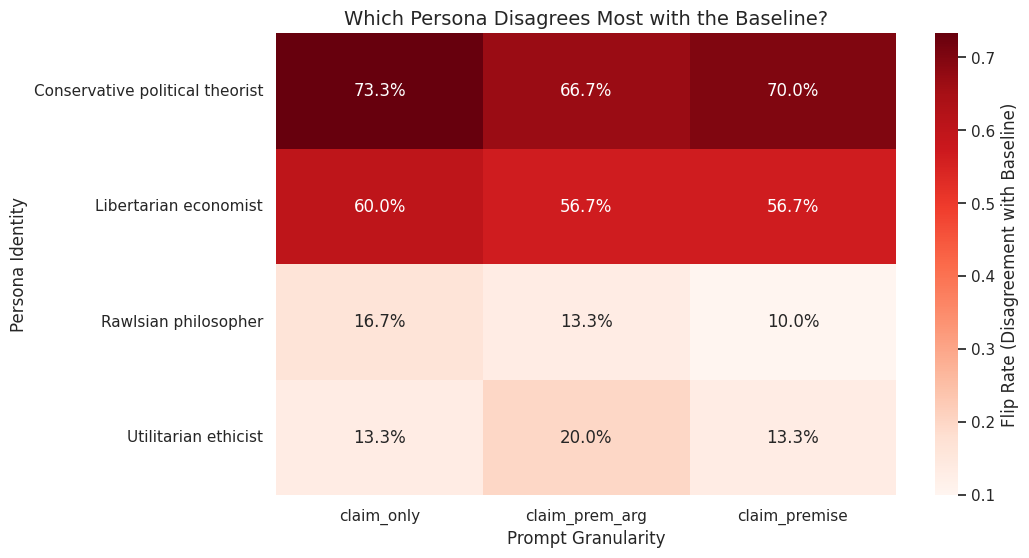

In [ ]:
persona_consistency = df_zero_shot.groupby(['persona', 'prompt_type'])['stance_consistent'].mean().unstack()

persona_flip_rate = 1 - persona_consistency

print("\n=== Flip Rate by Persona (Higher = More Distinct from Baseline) ===")
print(persona_flip_rate)


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(persona_flip_rate, annot=True, cmap="Reds", fmt=".1%", cbar_kws={'label': 'Flip Rate (Disagreement with Baseline)'})
plt.title("Which Persona Disagrees Most with the Baseline?", fontsize=14)
plt.ylabel("Persona Identity")
plt.xlabel("Prompt Granularity")
plt.show()

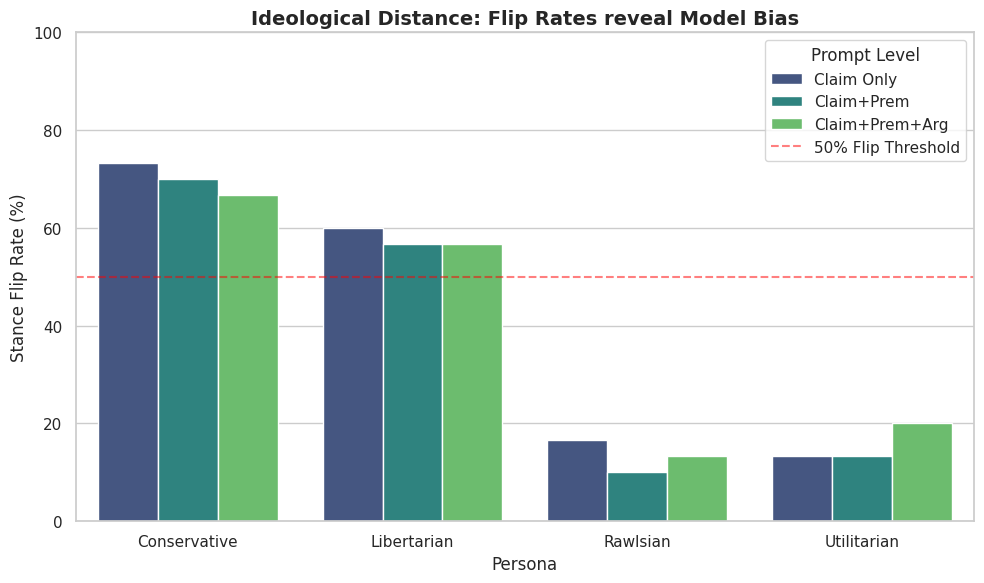

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


data = {
    'Persona': ['Conservative', 'Conservative', 'Conservative',
                'Libertarian', 'Libertarian', 'Libertarian',
                'Rawlsian', 'Rawlsian', 'Rawlsian',
                'Utilitarian', 'Utilitarian', 'Utilitarian'],
    'Prompt Type': ['Claim Only', 'Claim+Prem', 'Claim+Prem+Arg'] * 4,
    'Flip Rate': [73.3, 70.0, 66.7,  # Conservative
                  60.0, 56.7, 56.7,  # Libertarian
                  16.7, 10.0, 13.3,  # Rawlsian
                  13.3, 13.3, 20.0]  # Utilitarian
}
df_viz = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Persona', y='Flip Rate', hue='Prompt Type', data=df_viz, palette='viridis')


plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% Flip Threshold')

plt.title('Ideological Distance: Flip Rates reveal Model Bias', fontsize=14, fontweight='bold')
plt.ylabel('Stance Flip Rate (%)', fontsize=12)
plt.xlabel('Persona', fontsize=12)
plt.legend(title='Prompt Level')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

1. Effectiveness of Persona:

$$Distance(A, B) = 1 - \frac{A \cdot B}{\|A\| \|B\|}$$

$Distance = 1 - CosineSimilarity(Vec_{Baseline}, Vec_{Persona})$

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
df_baseline['embedding'] = df_baseline['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))
df_zero_shot['embedding'] = df_zero_shot['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))

# Cosine Distance vs baseline
from sentence_transformers import util
df_zero_shot['cosine_distance'] = df_zero_shot.apply(
    lambda row: 1 - util.cos_sim(row['embedding'], df_baseline.loc[df_baseline['index']==row['index'], 'embedding'].values[0]).item(),
    axis=1
)

summary = df_zero_shot.groupby('prompt_type')['cosine_distance'].agg(['mean','std','count']).reset_index()
print(summary)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

      prompt_type      mean       std  count
0      claim_only  0.240563  0.079661    120
1  claim_prem_arg  0.289935  0.093186    120
2   claim_premise  0.270740  0.094068    120


In [ ]:
from scipy.stats import ttest_rel
import numpy as np

df_sorted = df_zero_shot.sort_values('index')


co = df_sorted[df_sorted['prompt_type']=='claim_only']['cosine_distance'].tolist()
cp = df_sorted[df_sorted['prompt_type']=='claim_premise']['cosine_distance'].tolist()
cpa = df_sorted[df_sorted['prompt_type']=='claim_prem_arg']['cosine_distance'].tolist()

if len(co) == len(cp) == len(cpa):

    print("claim_only vs claim_premise:", ttest_rel(co, cp))
    print("claim_only vs claim_prem_arg:", ttest_rel(co, cpa))
    print("claim_premise vs claim_prem_arg:", ttest_rel(cp, cpa))
else:
    print("error")

from scipy.stats import wilcoxon
print("\nWilcoxon Test (Non-parametric alternative):")
print("co vs cp:", wilcoxon(co, cp))

claim_only vs claim_premise: TtestResult(statistic=np.float64(-3.388398178363797), pvalue=np.float64(0.0009538820819530727), df=np.int64(119))
claim_only vs claim_prem_arg: TtestResult(statistic=np.float64(-5.615377228916127), pvalue=np.float64(1.3064786149706177e-07), df=np.int64(119))
claim_premise vs claim_prem_arg: TtestResult(statistic=np.float64(-2.053332079762986), pvalue=np.float64(0.042232038540663), df=np.int64(119))

Wilcoxon Test (Non-parametric alternative):
co vs cp: WilcoxonResult(statistic=np.float64(2188.0), pvalue=np.float64(0.00015910549678711493))


/tmp/ipython-input-2241555319.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(x='prompt_type', y='cosine_distance', data=df_zero_shot,


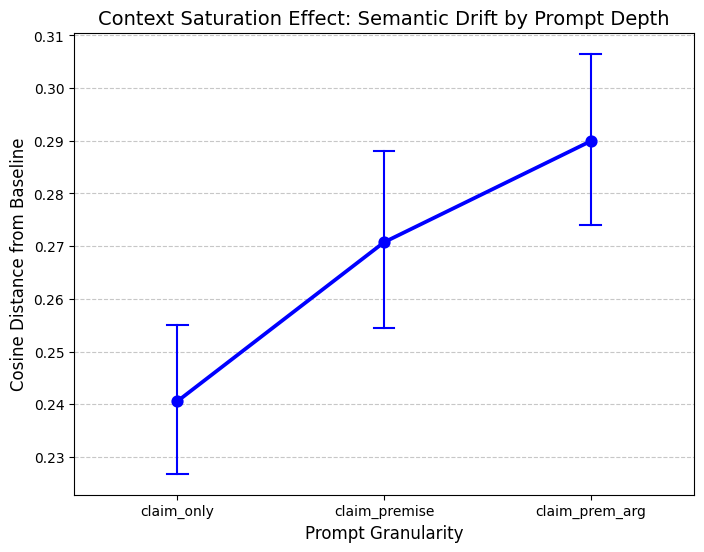

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.pointplot(x='prompt_type', y='cosine_distance', data=df_zero_shot,
              order=['claim_only', 'claim_premise', 'claim_prem_arg'],
              capsize=.1, errwidth=1.5, color='b')

plt.title('Context Saturation Effect: Semantic Drift by Prompt Depth', fontsize=14)
plt.ylabel('Cosine Distance from Baseline', fontsize=12)
plt.xlabel('Prompt Granularity', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

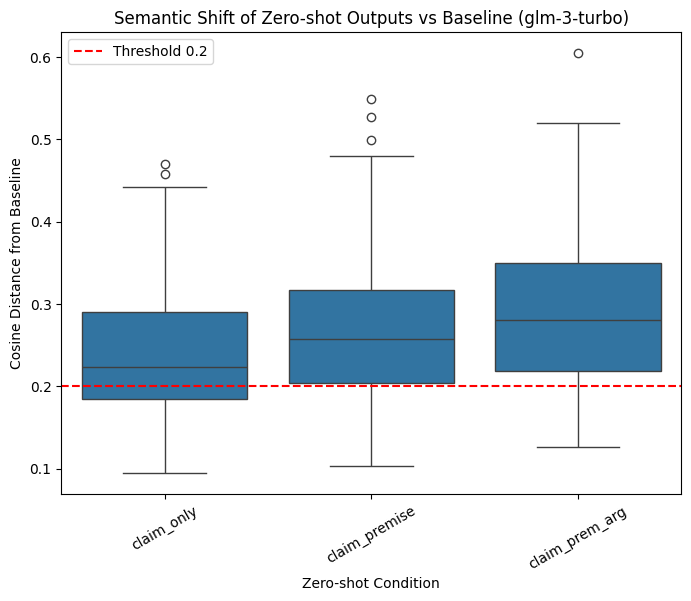

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='prompt_type', y='cosine_distance', data=df_zero_shot)
plt.axhline(0.2, color='red', linestyle='--', label='Threshold 0.2')
plt.ylabel("Cosine Distance from Baseline")
plt.xlabel("Zero-shot Condition")
plt.title("Semantic Shift of Zero-shot Outputs vs Baseline (glm-3-turbo)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

Interaction Effect Analysis: 3 Prompt  × flip or not

The Cost of Flipping v.s. Reframing within Agreement

/tmp/ipython-input-2490246337.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(
/tmp/ipython-input-2490246337.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Claim Only', 'Claim+Premise', 'Claim+Prem+Arg'], fontsize=11)
/tmp/ipython-input-2490246337.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_vals_flip = df_zero_shot[df_zero_shot['flip']==True].groupby('prompt_type')['cosine_distance'].mean()
/tmp/ipython-input-2490246337.py:60: FutureWarning: The default of observed=False is deprecated and 

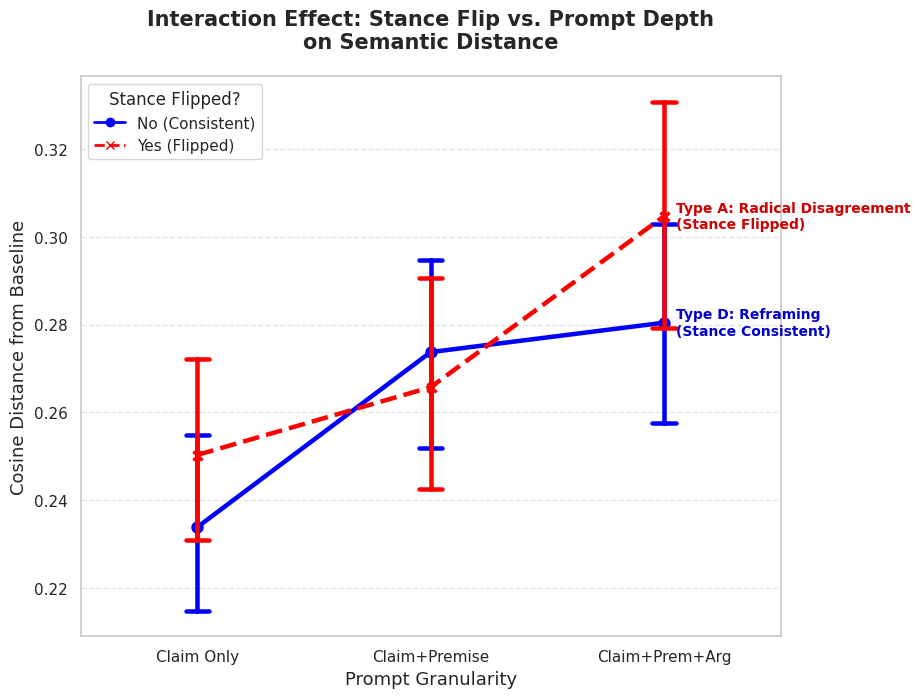


=== Descriptive Statistics for the 6 Sub-groups ===
                          mean       std  count
prompt_type    flip                            
claim_only     False  0.233843  0.084075     71
               True   0.250301  0.072530     49
claim_premise  False  0.273737  0.098582     75
               True   0.265746  0.086871     45
claim_prem_arg False  0.280439  0.097220     73
               True   0.304683  0.085467     47

=== T-test: Impact of Flipping within each Prompt Stage ===
Condition            | Delta (Flip - NoFlip) | p-value    | Sig.
-----------------------------------------------------------------
claim_only           | 0.0165               | 0.2550     | n.s.
claim_premise        | -0.0080               | 0.6440     | n.s.
claim_prem_arg       | 0.0242               | 0.1538     | n.s.


/tmp/ipython-input-2490246337.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = df_zero_shot.groupby(['prompt_type', 'flip'])['cosine_distance'].agg(['mean', 'std', 'count'])


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd

# ==========================================
# 1. Preparation
# ==========================================
# Ensure correct categorical order for the X-axis
order_list = ['claim_only', 'claim_premise', 'claim_prem_arg']
df_zero_shot['prompt_type'] = pd.Categorical(
    df_zero_shot['prompt_type'],
    categories=order_list,
    ordered=True
)

# Ensure 'flip' is boolean (True = Stance Changed, False = Consistent)
# If you haven't created it yet, uncomment the line below:
# df_zero_shot['flip'] = df_zero_shot['stance_consistent'] == 0

# ==========================================
# 2. Visualization: Interaction Plot
# ==========================================
plt.figure(figsize=(10, 7))

# Create the point plot
ax = sns.pointplot(
    data=df_zero_shot,
    x='prompt_type',
    y='cosine_distance',
    hue='flip',
    palette={False: 'blue', True: 'red'},
    markers=['o', 'x'],
    linestyles=['-', '--'],
    capsize=0.1,
    scale=1.2,
    errorbar=('ci', 95)  # 95% Confidence Interval
)

# Custom Legend Definition
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, marker='o', label='No (Consistent)'),
    Line2D([0], [0], color='red', lw=2, ls='--', marker='x', label='Yes (Flipped)')
]

# Add legend
ax.legend(handles=legend_elements, title='Stance Flipped?', loc='upper left', fontsize=11, title_fontsize=12)

# Formatting
plt.title('Interaction Effect: Stance Flip vs. Prompt Depth\non Semantic Distance', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Prompt Granularity', fontsize=13)
plt.ylabel('Cosine Distance from Baseline', fontsize=13)
ax.set_xticklabels(['Claim Only', 'Claim+Premise', 'Claim+Prem+Arg'], fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Dynamic Annotations (Type A vs Type D)
# Calculate means for positioning text
y_vals_flip = df_zero_shot[df_zero_shot['flip']==True].groupby('prompt_type')['cosine_distance'].mean()
y_vals_no = df_zero_shot[df_zero_shot['flip']==False].groupby('prompt_type')['cosine_distance'].mean()

# Annotation: Radical Disagreement
plt.text(2.05, y_vals_flip['claim_prem_arg'],
         "Type A: Radical Disagreement\n(Stance Flipped)",
         color='#cc0000', fontsize=10, fontweight='bold', ha='left', va='center')

# Annotation: Reframing
plt.text(2.05, y_vals_no['claim_prem_arg'],
         "Type D: Reframing\n(Stance Consistent)",
         color='#0000cc', fontsize=10, fontweight='bold', ha='left', va='center')

# Adjust margins to fit annotations
plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1)

plt.show()

# ==========================================
# 3. Statistical Analysis (The 6 Groups)
# ==========================================

print("\n=== Descriptive Statistics for the 6 Sub-groups ===")
# Group by Prompt Type and Flip Status to get Mean, SD, and Count
summary_stats = df_zero_shot.groupby(['prompt_type', 'flip'])['cosine_distance'].agg(['mean', 'std', 'count'])
print(summary_stats)

print("\n=== T-test: Impact of Flipping within each Prompt Stage ===")
print(f"{'Condition':<20} | {'Delta (Flip - NoFlip)':<20} | {'p-value':<10} | {'Sig.'}")
print("-" * 65)

for p_type in order_list:
    # Isolate the two groups for the current prompt type
    group_flip = df_zero_shot[(df_zero_shot['prompt_type'] == p_type) & (df_zero_shot['flip'] == True)]['cosine_distance']
    group_no_flip = df_zero_shot[(df_zero_shot['prompt_type'] == p_type) & (df_zero_shot['flip'] == False)]['cosine_distance']

    # Perform T-test if data is sufficient
    if len(group_flip) > 1 and len(group_no_flip) > 1:
        t_stat, p_val = ttest_ind(group_flip, group_no_flip, equal_var=False)

        # Determine significance stars
        if p_val < 0.001: sig = "***"
        elif p_val < 0.01: sig = "**"
        elif p_val < 0.05: sig = "*"
        else: sig = "n.s."

        diff = group_flip.mean() - group_no_flip.mean()
        print(f"{p_type:<20} | {diff:.4f}{' '*14} | {p_val:.4f}     | {sig}")
    else:
        print(f"{p_type:<20} | Insufficient data for T-test")

$$t = \frac{\text{ (Signal)}}{\text{ (Noise)}} = \frac{\text{ (Mean Difference)}}{\text{ (Standard Error)}}$$

The lack of statistical significance ($p > 0.05$) is primarily driven by the high standard deviation ($\sigma \approx 0.09$) observed in the zero-shot responses. This indicates that without examples (zero-shot), the model's performance is highly volatile—sometimes producing radical disagreements, and other times producing mild ones, regardless of the stance flipping."

2. Lexical Distinctiveness

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


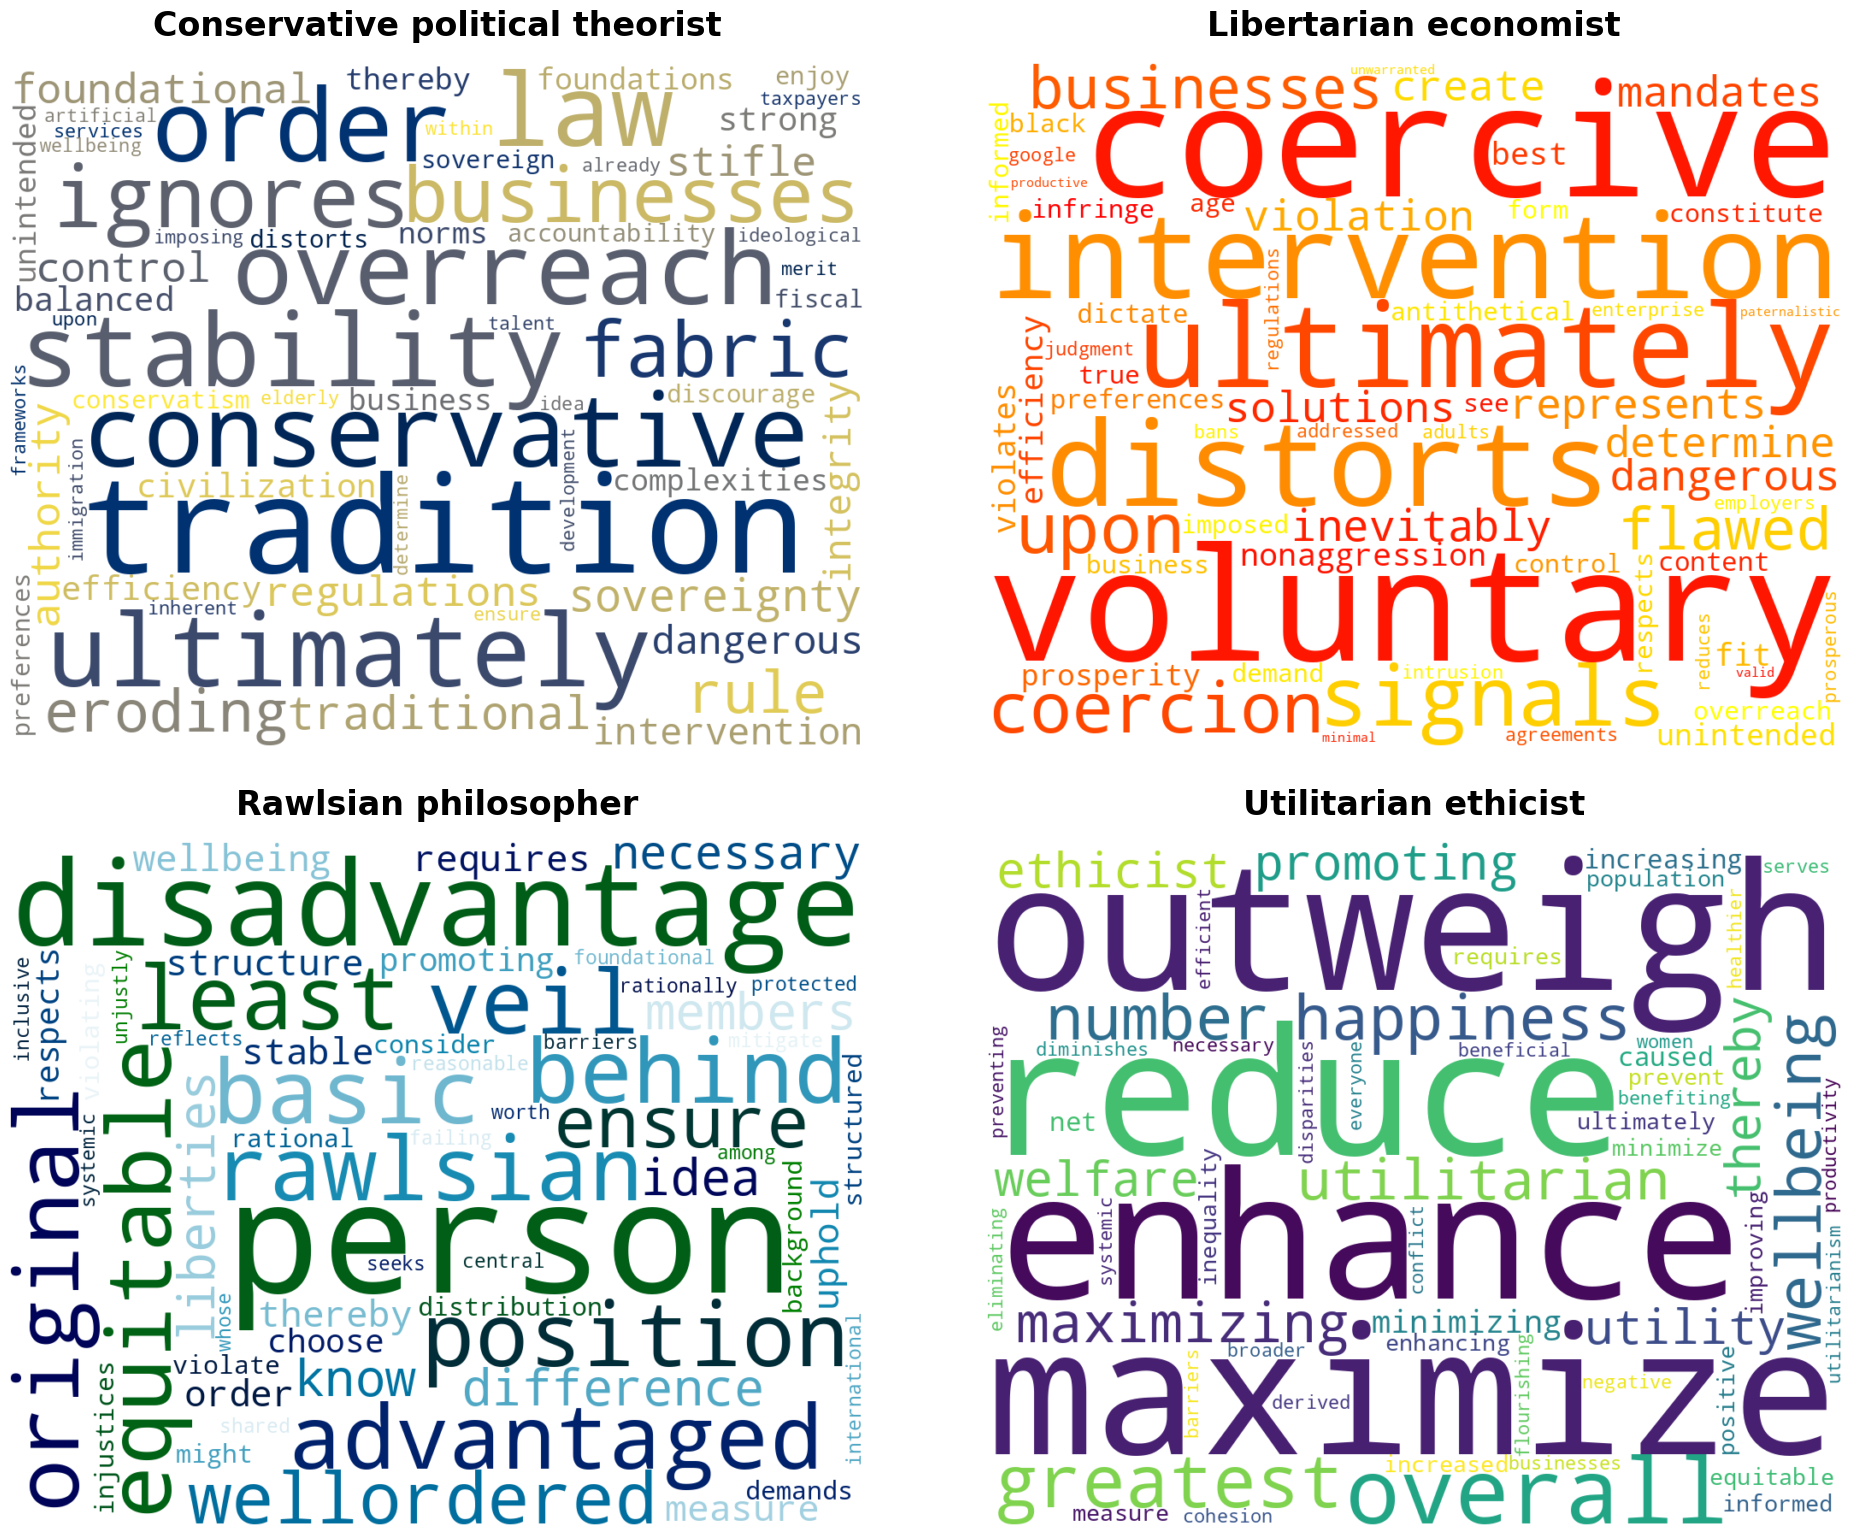

In [ ]:
import pandas as pd
import re
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
domain_stops = {
    'argument', 'premise', 'claim', 'would', 'could', 'should',
    'support', 'oppose', 'stance', 'response', 'therefore',
    'however', 'perspective', 'view', 'opinion', 'believe',
    'society', 'individual', 'people', 'must', 'us',
    'example', 'instance', 'case'
}
stop_words.update(domain_stops)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

def extract_keywords(df, k=50):
    target_col = 'argument' if 'argument' in df.columns else 'response'

    grouped = df.groupby('persona')[target_col].apply(lambda x: " ".join(str(v) for v in x)).reset_index()
    grouped['clean_text'] = grouped[target_col].apply(preprocess_text)

    vectorizer = TfidfVectorizer(max_df=0.8, max_features=2000)
    try:
        tfidf_matrix = vectorizer.fit_transform(grouped['clean_text'])
    except ValueError:
        return {}

    feature_names = vectorizer.get_feature_names_out()
    keywords_map = {}

    for i, row in grouped.iterrows():
        persona_name = row['persona']
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[::-1][:k]
        keywords_map[persona_name] = [feature_names[idx] for idx in top_indices]

    return keywords_map

def generate_wordcloud_grid(keywords_map, output_filename="zero_shot_lexical_grid.png"):
    personas = list(keywords_map.keys())
    n_personas = len(personas)
    cols = 2
    rows = math.ceil(n_personas / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))
    axes = axes.flatten()

    colormaps = {
        'Libertarian economist': 'autumn',
        'Conservative political theorist': 'cividis',
        'Rawlsian philosopher': 'ocean',
        'Utilitarian ethicist': 'viridis'
    }
    default_cmap = 'coolwarm'

    for i, persona_name in enumerate(personas):
        ax = axes[i]
        word_list = keywords_map[persona_name]
        text_data = " ".join(word_list)

        wc = WordCloud(
            width=1000,
            height=800,
            background_color='white',
            max_words=60,
            colormap=colormaps.get(persona_name, default_cmap),
            collocations=False,
            random_state=42
        )
        wc.generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(persona_name, fontsize=24, fontweight='bold', pad=20)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=3.0)
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

df_filtered = df_zero_shot[df_zero_shot['persona'] != 'Baseline'].copy()
top_keywords_zeroshot = extract_keywords(df_filtered, k=60)

if top_keywords_zeroshot:
    generate_wordcloud_grid(top_keywords_zeroshot)
else:
    print("Error: Failed to extract keywords.")

Distinct Lexical Clusters
>0.3.  /.  < 0.15

In [ ]:
def calculate_overlap_metrics(keywords_map, top_k=50):
    import itertools

    personas = list(keywords_map.keys())
    persona_sets = {p: set(keywords_map[p][:top_k]) for p in personas}


    for p1, p2 in itertools.combinations(personas, 2):
        set1 = persona_sets[p1]
        set2 = persona_sets[p2]

        intersection = set1.intersection(set2)
        union = set1.union(set2)

        # Jaccard Score
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0

        print(f"{p1} vs {p2}:")
        print(f"  - Jaccard Score: {jaccard:.4f}")
        print(f"  - Overlapping Words: {list(intersection) if intersection else 'None'}")
        print("-" * 30)


if 'top_keywords_zeroshot' in locals() and top_keywords_zeroshot:
    print("Detected 'top_keywords_zeroshot'. Running analysis...")
    calculate_overlap_metrics(top_keywords_zeroshot, top_k=50)


else:
    print("Error: cannot find the keywords")

Detected 'top_keywords_zeroshot'. Running analysis...
Conservative political theorist vs Libertarian economist:
  - Jaccard Score: 0.1364
  - Overlapping Words: ['ultimately', 'businesses', 'intervention', 'dangerous', 'distorts', 'preferences', 'control', 'unintended', 'business', 'upon', 'efficiency', 'overreach']
------------------------------
Conservative political theorist vs Rawlsian philosopher:
  - Jaccard Score: 0.0417
  - Overlapping Words: ['foundational', 'thereby', 'ensure', 'order']
------------------------------
Conservative political theorist vs Utilitarian ethicist:
  - Jaccard Score: 0.0309
  - Overlapping Words: ['ultimately', 'businesses', 'thereby']
------------------------------
Libertarian economist vs Rawlsian philosopher:
  - Jaccard Score: 0.0101
  - Overlapping Words: ['respects']
------------------------------
Libertarian economist vs Utilitarian ethicist:
  - Jaccard Score: 0.0417
  - Overlapping Words: ['ultimately', 'reduces', 'informed', 'businesses']
--

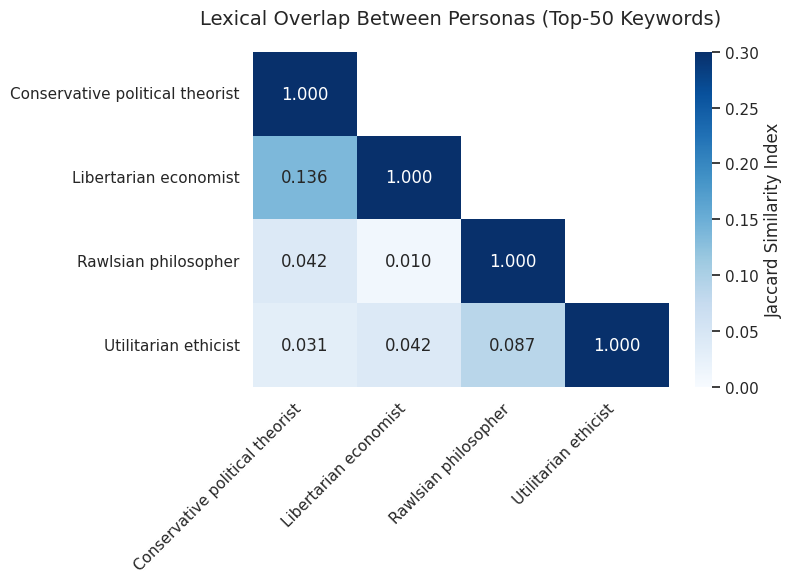

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import itertools

def plot_jaccard_heatmap(keywords_map, top_k=50):
    personas = list(keywords_map.keys())
    n = len(personas)
    matrix = np.zeros((n, n))

    persona_sets = {p: set(keywords_map[p][:top_k]) for p in personas}

    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i][j] = 1.0
            else:
                p1, p2 = personas[i], personas[j]
                set1 = persona_sets[p1]
                set2 = persona_sets[p2]
                intersection = len(set1.intersection(set2))
                union = len(set1.union(set2))
                matrix[i][j] = intersection / union if union > 0 else 0


    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")

    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

    sns.heatmap(
        matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        xticklabels=personas,
        yticklabels=personas,
        vmin=0, vmax=0.3,
        cbar_kws={'label': 'Jaccard Similarity Index'}
    )

    plt.title(f'Lexical Overlap Between Personas (Top-{top_k} Keywords)', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

if 'top_keywords_zeroshot' in locals() and top_keywords_zeroshot:
    plot_jaccard_heatmap(top_keywords_zeroshot, top_k=50)

3. Stance Consistency

In [ ]:
df_zero_shot['stance'] = df_zero_shot['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_baseline['stance'] = df_baseline['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_zero_shot['flip'] = df_zero_shot.apply(
    lambda row: row['stance'] != df_baseline.loc[df_baseline['index'] == row['index'], 'stance'].values[0],
    axis=1
)

flip_rate = df_zero_shot.groupby(['persona', 'prompt_type'])['flip'].mean().reset_index()
flip_rate['flip_percentage'] = flip_rate['flip'] * 100
print(flip_rate)

                            persona     prompt_type      flip  flip_percentage
0   Conservative political theorist      claim_only  0.733333        73.333333
1   Conservative political theorist  claim_prem_arg  0.666667        66.666667
2   Conservative political theorist   claim_premise  0.700000        70.000000
3             Libertarian economist      claim_only  0.600000        60.000000
4             Libertarian economist  claim_prem_arg  0.566667        56.666667
5             Libertarian economist   claim_premise  0.566667        56.666667
6              Rawlsian philosopher      claim_only  0.166667        16.666667
7              Rawlsian philosopher  claim_prem_arg  0.133333        13.333333
8              Rawlsian philosopher   claim_premise  0.100000        10.000000
9              Utilitarian ethicist      claim_only  0.133333        13.333333
10             Utilitarian ethicist  claim_prem_arg  0.200000        20.000000
11             Utilitarian ethicist   claim_premise 

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

baseline_flip_rate = 0.0367  # 3.67%
noise_nobs = 30
noise_flips_count = baseline_flip_rate * noise_nobs


results = []

for persona in df_zero_shot['persona'].unique():
    for prompt in df_zero_shot['prompt_type'].unique():

        subset = df_zero_shot[(df_zero_shot['persona']==persona) &
                              (df_zero_shot['prompt_type']==prompt)]


        persona_flips_count = subset['flip'].sum()
        persona_nobs = len(subset)


        count = np.array([persona_flips_count, noise_flips_count])
        nobs = np.array([persona_nobs, noise_nobs])


        try:
            stat, p_value = proportions_ztest(count, nobs, alternative='larger')
        except:
            p_value = 1.0

        results.append({
            "model": "ChatGLM-3-Turbo",
            "persona": persona,
            "prompt_type": prompt,
            "persona_flip_rate": f"{persona_flips_count/persona_nobs:.2%}",
            "noise_baseline": "3.67%",
            "p_value": round(p_value, 4),
            "is_significant": "Yes" if p_value < 0.05 else "No"
        })

df_final_stats = pd.DataFrame(results)
print(df_final_stats)

              model                          persona     prompt_type  \
0   ChatGLM-3-Turbo             Rawlsian philosopher      claim_only   
1   ChatGLM-3-Turbo             Rawlsian philosopher   claim_premise   
2   ChatGLM-3-Turbo             Rawlsian philosopher  claim_prem_arg   
3   ChatGLM-3-Turbo            Libertarian economist      claim_only   
4   ChatGLM-3-Turbo            Libertarian economist   claim_premise   
5   ChatGLM-3-Turbo            Libertarian economist  claim_prem_arg   
6   ChatGLM-3-Turbo             Utilitarian ethicist      claim_only   
7   ChatGLM-3-Turbo             Utilitarian ethicist   claim_premise   
8   ChatGLM-3-Turbo             Utilitarian ethicist  claim_prem_arg   
9   ChatGLM-3-Turbo  Conservative political theorist      claim_only   
10  ChatGLM-3-Turbo  Conservative political theorist   claim_premise   
11  ChatGLM-3-Turbo  Conservative political theorist  claim_prem_arg   

   persona_flip_rate noise_baseline  p_value is_significant  
0

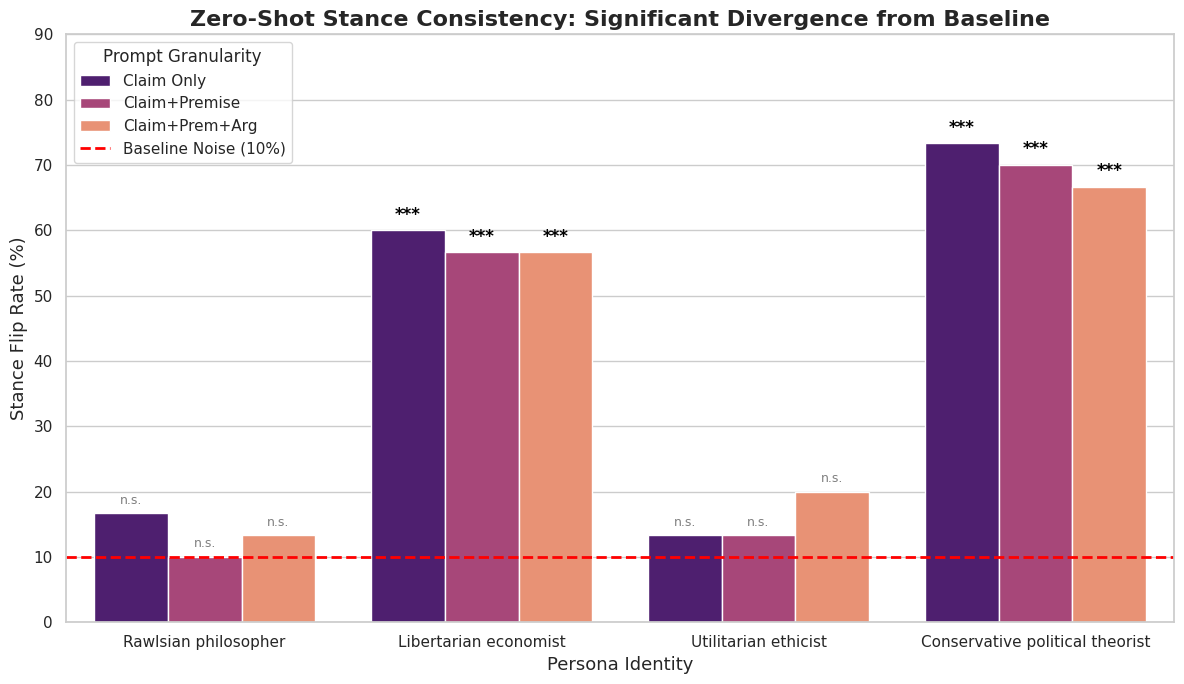

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = df_final_stats.copy()


df_plot['flip_val'] = df_plot['persona_flip_rate'].str.rstrip('%').astype(float)

df_plot['prompt_label'] = df_plot['prompt_type'].replace({
    'claim_only': 'Claim Only',
    'claim_premise': 'Claim+Premise',
    'claim_prem_arg': 'Claim+Prem+Arg'
})


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")


ax = sns.barplot(
    x='persona',
    y='flip_val',
    hue='prompt_label',
    data=df_plot,
    palette='magma'
)


plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Baseline Noise (10%)')


for container in ax.containers:
    for bar in container:

        height = bar.get_height()

        if height > 20:
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                '***',
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold'
            )
        else:
             ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                'n.s.',
                ha='center', va='bottom', fontsize=9, color='gray'
            )

plt.title('Zero-Shot Stance Consistency: Significant Divergence from Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Stance Flip Rate (%)', fontsize=13)
plt.xlabel('Persona Identity', fontsize=13)
plt.ylim(0, 90)
plt.legend(title='Prompt Granularity', loc='upper left')

plt.tight_layout()
plt.show()

4. Cross-Prompt Consistency Analysis (Prompt Sensitivity Test, Robustness)

In [ ]:
def extract_stance(df):
    df = df.copy()
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:", "").strip())
    return df[['index', 'persona', 'stance']]

df_claim_only_s = extract_stance(df_claim_only).rename(columns={'stance':'stance_claim_only'})
df_claim_prem_s = extract_stance(df_claim_prem).rename(columns={'stance':'stance_claim_prem'})
df_claim_prem_arg_s = extract_stance(df_claim_prem_arg).rename(columns={'stance':'stance_claim_prem_arg'})

df_stance = df_claim_only_s.merge(df_claim_prem_s, on=['index','persona'])
df_stance = df_stance.merge(df_claim_prem_arg_s, on=['index','persona'])

In [ ]:
df_stance['all_equal'] = (df_stance['stance_claim_only'] == df_stance['stance_claim_prem']) & \
                         (df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg'])

df_stance['only_vs_prem'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem']
df_stance['only_vs_premarg'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg']
df_stance['prem_vs_premarg'] = df_stance['stance_claim_prem'] == df_stance['stance_claim_prem_arg']


In [ ]:
total = len(df_stance)
all_equal_ratio = df_stance['all_equal'].sum() / total
only_vs_prem_ratio = df_stance['only_vs_prem'].sum() / total
only_vs_premarg_ratio = df_stance['only_vs_premarg'].sum() / total
prem_vs_premarg_ratio = df_stance['prem_vs_premarg'].sum() / total

print(f"All three prompts equal: {all_equal_ratio:.2f}") # Rigidity
print(f"claim_only vs claim_prem: {only_vs_prem_ratio:.2f}") # Persuasiveness/Context Impact
print(f"claim_only vs claim_prem_arg: {only_vs_premarg_ratio:.2f}") # Marginal Utility of Argument
print(f"claim_prem vs claim_prem_arg: {prem_vs_premarg_ratio:.2f}")

All three prompts equal: 0.84
claim_only vs claim_prem: 0.90
claim_only vs claim_prem_arg: 0.87
claim_prem vs claim_prem_arg: 0.92


5. Topic

In [ ]:
import pandas as pd

# 10 topics, each with 3 arguments
topics = [
    "Culture", "Digital Freedoms", "Economy", "Education", "Environment",
    "Health", "Science", "Religion", "Philosophy", "Society"
]

# Assign each of the 30 unique arguments to a topic
topic_list = []
for t in topics:
    topic_list.extend([t]*3)  # each topic has 3 arguments

# Create a DataFrame mapping argument index to topic
df_topic = pd.DataFrame({
    'index': range(1, 31),  # argument indices 1 to 30
    'topic': topic_list
})

# Merge topic information into the stance DataFrame
df_stance_topic = df_stance.merge(df_topic, on='index', how='left')

# Calculate stance inconsistency per topic
# Use only 'all_equal' column in lambda to avoid the DeprecationWarning
topic_inconsistency = df_stance_topic.groupby('topic')['all_equal'].apply(
    lambda x: 1 - x.mean()
).sort_values(ascending=False)

# Print the inconsistency ratios
print("Topic inconsistency ratios:")
print(topic_inconsistency)

Topic inconsistency ratios:
topic
Digital Freedoms    0.250000
Environment         0.250000
Religion            0.250000
Philosophy          0.250000
Science             0.166667
Health              0.166667
Society             0.166667
Education           0.083333
Culture             0.000000
Economy             0.000000
Name: all_equal, dtype: float64


/tmp/ipython-input-1943784984.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='magma')


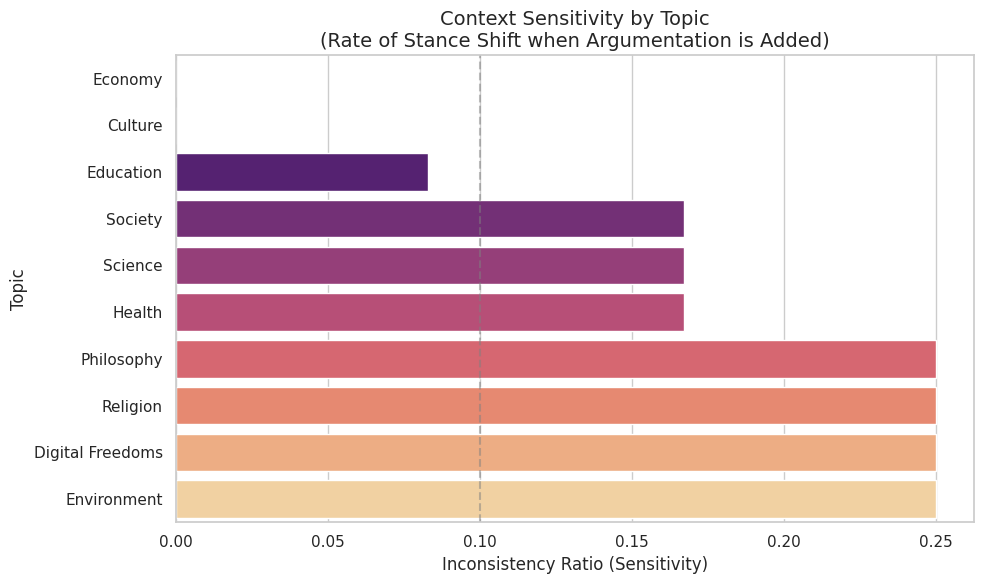

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    'Digital Freedoms': 0.25, 'Environment': 0.25, 'Religion': 0.25, 'Philosophy': 0.25,
    'Science': 0.167, 'Health': 0.167, 'Society': 0.167,
    'Education': 0.083, 'Culture': 0.0, 'Economy': 0.0
}


df_plot = pd.DataFrame(list(data.items()), columns=['Topic', 'Inconsistency Ratio'])
df_plot = df_plot.sort_values('Inconsistency Ratio', ascending=True) #

plt.figure(figsize=(10, 6))

sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='magma')

plt.title('Context Sensitivity by Topic\n(Rate of Stance Shift when Argumentation is Added)', fontsize=14)
plt.xlabel('Inconsistency Ratio (Sensitivity)', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()